In [4]:
import sys
!{sys.executable} -m pip install yfinance

  Using cached yfinance-1.4.1-py2.py3-none-any.whl.metadata (6.2 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached peewee-4.0.6-py3-none-any.whl.metadata (8.6 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-macosx_11_0_arm64.whl.metadata (18 kB)
  Using cached websockets-16.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.8 kB)
Using cached yfinance-1.4.1-py2.py3-none-any.whl (137 kB)
Using cached curl_cffi-0.15.0-cp310-abi3-macosx_11_0_arm64.whl (2.6 MB)
Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)
Using cached peewee-4.0.6-py3-none-any.whl (146 kB)
Using cached websockets-16.0-cp313-cp313-macosx_11_0_arm64.whl (175 kB)
  Attempting uninstall: cffi━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━ 3/7 [protobuf]
    Found existing installation: cffi 1.17.1;237m╺━━━━━━━━━━━━━━━━━━━━━━ 3/7 [protobuf]
    Uninstalling cffi-1.17.1:━━━━━╺━━━━━━━━━━━━━━━━━━━━━━ 3/7 [protobuf]
      Successfully uninstalled cffi-1.17.1━╸━━━━━━━━━━━━━━━━━ 4/7 [cffi]
   ━━━━━━━━

In [3]:
import yfinance as yf

# Definimos nuestras 3 empresas
tickers = ['LMT', 'NOC', 'BA.L']

# Descargamos la información de Lockheed primero para explorar
lmt = yf.Ticker('LMT')

# Veamos el estado de resultados
lmt.financials

,2025-12-31,2024-12-31,2023-12-31,2022-12-31,2021-12-31
Tax Effect Of Unusual Items,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
Tax Rate For Calcs,1.528200e-01,1.421220e-01,1.450000e-01,1.419160e-01,NaN
Normalized EBITDA,8.727000e+09,8.815000e+09,1.044400e+10,8.707000e+09,NaN
Net Income From Continuing Operation Net Minority Interest,5.017000e+09,5.336000e+09,6.920000e+09,5.732000e+09,NaN
Reconciled Depreciation,1.687000e+09,1.559000e+09,1.430000e+09,1.404000e+09,NaN
Reconciled Cost Of Revenue,6.742900e+10,6.411300e+10,5.909200e+10,5.769700e+10,NaN
EBITDA,8.727000e+09,8.815000e+09,1.044400e+10,8.707000e+09,NaN
EBIT,7.040000e+09,7.256000e+09,9.014000e+09,7.303000e+09,NaN
Net Interest Income,-1.118000e+09,-1.036000e+09,-9.160000e+08,-6.230000e+08,NaN
Interest Expense,1.118000e+09,1.036000e+09,9.160000e+08,6.230000e+08,NaN


In [4]:
import pandas as pd

# Extraemos el ingreso total y utilidad neta
financials = lmt.financials

# Filas que nos interesan
metricas = ['Total Revenue', 'Net Income']

lmt_resultados = financials.loc[metricas]

print(lmt_resultados)

                 2025-12-31    2024-12-31    2023-12-31    2022-12-31  \
Total Revenue  7.504800e+10  7.104300e+10  6.757100e+10  6.598400e+10   
Net Income     5.017000e+09  5.336000e+09  6.920000e+09  5.732000e+09   

               2021-12-31  
Total Revenue         NaN  
Net Income            NaN  


In [5]:
# Convertimos a millones para hacerlo legible
lmt_resultados_m = lmt_resultados / 1e6

# Redondeamos a 2 decimales
lmt_resultados_m = lmt_resultados_m.round(2)

print(lmt_resultados_m)

               2025-12-31  2024-12-31  2023-12-31  2022-12-31  2021-12-31
Total Revenue     75048.0     71043.0     67571.0     65984.0         NaN
Net Income         5017.0      5336.0      6920.0      5732.0         NaN


In [6]:
# Calculamos el crecimiento año con año
# Primero ordenamos las columnas de mas antiguo a mas reciente
lmt_revenue = lmt_resultados_m.loc['Total Revenue'].dropna().sort_index()

# Calculamos YoY en porcentaje
yoy_growth = lmt_revenue.pct_change() * 100
yoy_growth = yoy_growth.round(2)

print("Ingresos LMT (USD Millones):")
print(lmt_revenue)
print("\nCrecimiento YoY (%):")
print(yoy_growth)

Ingresos LMT (USD Millones):
2022-12-31    65984.0
2023-12-31    67571.0
2024-12-31    71043.0
2025-12-31    75048.0
Name: Total Revenue, dtype: float64

Crecimiento YoY (%):
2022-12-31     NaN
2023-12-31    2.41
2024-12-31    5.14
2025-12-31    5.64
Name: Total Revenue, dtype: float64


In [7]:
utilidad_neta = lmt_resultados_m.loc['Net Income'].dropna().sort_index()
print(utilidad_neta)

2022-12-31    5732.0
2023-12-31    6920.0
2024-12-31    5336.0
2025-12-31    5017.0
Name: Net Income, dtype: float64


In [8]:
# Margen neto para todos los años
margen_neto = (utilidad_neta / lmt_revenue) * 100
margen_neto = margen_neto.round(2)

print("Margen Neto LMT (%):")
print(margen_neto)

Margen Neto LMT (%):
2022-12-31     8.69
2023-12-31    10.24
2024-12-31     7.51
2025-12-31     6.69
dtype: float64


In [9]:
# Definimos las empresas
empresas = ['LMT', 'NOC', 'BA.L']
metricas = ['Total Revenue', 'Net Income']

# Diccionario para guardar resultados
datos = {}

for ticker in empresas:
    empresa = yf.Ticker(ticker)
    financials = empresa.financials
    datos[ticker] = (financials.loc[metricas] / 1e6).round(2)

# Ver resultados de NOC
print(datos['NOC'])


               2025-12-31  2024-12-31  2023-12-31  2022-12-31
Total Revenue     41954.0     41033.0     39290.0     36602.0
Net Income         4182.0      4174.0      2056.0      4896.0


In [10]:
noc_revenue = datos['NOC'].loc['Total Revenue'].dropna().sort_index()
noc_utilidad = datos['NOC'].loc['Net Income'].dropna().sort_index()

margen_noc = (noc_utilidad / noc_revenue * 100).round(2)
print("Margen Neto NOC (%):")
print(margen_noc)

Margen Neto NOC (%):
2022-12-31    13.38
2023-12-31     5.23
2024-12-31    10.17
2025-12-31     9.97
dtype: float64


In [11]:
# Obtenemos el tipo de cambio GBP/USD
gbp_usd = yf.Ticker("GBPUSD=X")

# Precio histórico del 2022 al 2025
tipo_cambio = gbp_usd.history(start="2022-01-01", end="2025-12-31")

# Promedio del período
tc_promedio = tipo_cambio['Close'].mean().round(4)

print(f"Tipo de cambio promedio GBP/USD 2022-2025: {tc_promedio}")

Tipo de cambio promedio GBP/USD 2022-2025: 1.2693


In [12]:
# Extraemos datos de BAE
bae_data = datos['BA.L']

# Convertimos de GBP a USD
bae_usd = (bae_data * tc_promedio).round(2)

# Extraemos revenue y utilidad
bae_revenue = bae_usd.loc['Total Revenue'].dropna().sort_index()
bae_utilidad = bae_usd.loc['Net Income'].dropna().sort_index()

# Calculamos margen
margen_bae = (bae_utilidad / bae_revenue * 100).round(2)

print("Ingresos BAE (USD Millones):")
print(bae_revenue)
print("\nMargen Neto BAE (%):")
print(margen_bae)

Ingresos BAE (USD Millones):
2022-12-31    26982.78
2023-12-31    29292.91
2024-12-31    33397.82
2025-12-31    35966.88
Name: Total Revenue, dtype: float64

Margen Neto BAE (%):
2022-12-31    7.48
2023-12-31    8.05
2024-12-31    7.43
2025-12-31    7.28
dtype: float64


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Consolidamos ingresos de las 3 empresas
ingresos = {
    'LMT': lmt_revenue,
    'NOC': noc_revenue,
    'BAE': bae_revenue
}

margenes = {
    'LMT': margen_neto,
    'NOC': margen_noc,
    'BAE': margen_bae
}

# Años para el eje X
años = ['2022', '2023', '2024', '2025']

print("Datos consolidados listos ✅")

Datos consolidados listos ✅


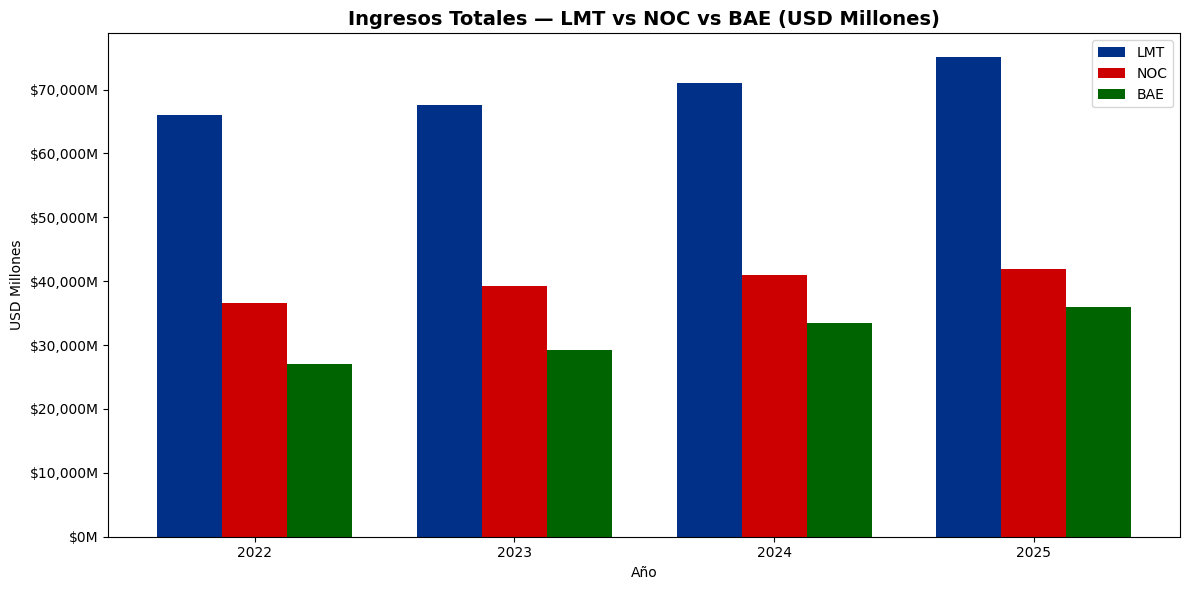

In [14]:
# Gráfica de barras - Ingresos Totales
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(años))
ancho = 0.25  # ancho de cada barra

# Una barra por empresa
ax.bar(x - ancho, ingresos['LMT'].values, ancho, label='LMT', color='#003087')
ax.bar(x, ingresos['NOC'].values, ancho, label='NOC', color='#CC0000')
ax.bar(x + ancho, ingresos['BAE'].values, ancho, label='BAE', color='#006400')

# Etiquetas y formato
ax.set_title('Ingresos Totales — LMT vs NOC vs BAE (USD Millones)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('USD Millones')
ax.set_xticks(x)
ax.set_xticklabels(años)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}M'))

plt.tight_layout()
plt.show()

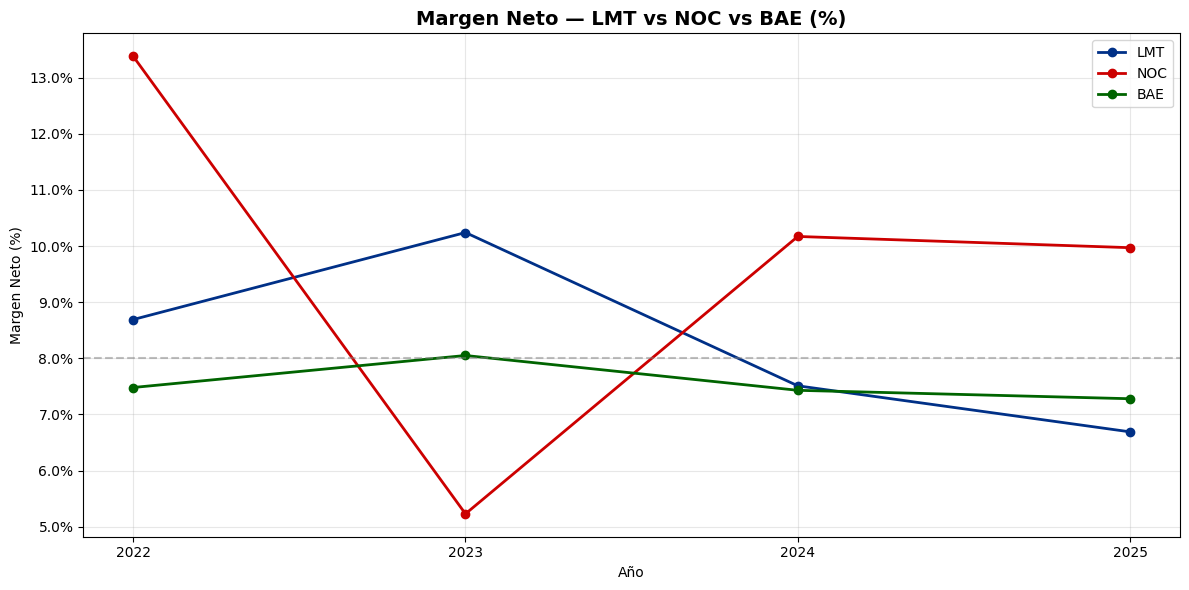

In [15]:
# Gráfica de líneas - Márgenes Netos
fig, ax = plt.subplots(figsize=(12, 6))

# Una línea por empresa
ax.plot(años, margenes['LMT'].values, marker='o', linewidth=2, 
        label='LMT', color='#003087')
ax.plot(años, margenes['NOC'].values, marker='o', linewidth=2, 
        label='NOC', color='#CC0000')
ax.plot(años, margenes['BAE'].values, marker='o', linewidth=2, 
        label='BAE', color='#006400')

# Etiquetas y formato
ax.set_title('Margen Neto — LMT vs NOC vs BAE (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Margen Neto (%)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}%'))

# Línea de referencia en el promedio
ax.axhline(y=8, color='gray', linestyle='--', alpha=0.5, label='Referencia 8%')

plt.tight_layout()
plt.show()

In [16]:
# Descargamos precio histórico de las 3 empresas
precios = yf.download(['LMT', 'NOC', 'BA.L'], 
                       start='2022-01-01', 
                       end='2025-12-31')['Close']

# Normalizamos a base 100 para comparar en la misma escala
# Es decir, todas empiezan en 100 el primer día
precios_norm = (precios / precios.iloc[0]) * 100

print(precios_norm.tail())

[*********************100%***********************]  3 of 3 completed

Ticker      BA.L         LMT         NOC
Date                                    
2025-12-23   NaN  151.639874  160.510357
2025-12-24   NaN  152.645459  161.144019
2025-12-26   NaN  151.790718  159.765994
2025-12-29   NaN  153.625912  159.879452
2025-12-30   NaN  153.352520  158.991202


In [17]:
precios = yf.download(['LMT', 'NOC', 'BA.L'], 
                       start='2022-01-01', 
                       end='2026-06-01')['Close']

precios_norm = (precios / precios.iloc[0]) * 100

print(precios_norm.tail())

[*********************100%***********************]  3 of 3 completed

Ticker      BA.L         LMT         NOC
Date                                    
2026-05-22   NaN  168.452172  154.228819
2026-05-26   NaN  168.344771  154.567492
2026-05-27   NaN  167.788768  153.051809
2026-05-28   NaN  169.706318  155.258708
2026-05-29   NaN  167.570803  156.477378


In [18]:
# Descargamos BAE por separado
bae_precios = yf.Ticker('BA.L').history(start='2022-01-01', end='2026-06-01')['Close']

# Verificamos que tiene datos
print(bae_precios.tail())
print(f"\nTotal de registros: {len(bae_precios)}")

Date
2026-05-22 00:00:00+01:00    1993.5
2026-05-26 00:00:00+01:00    1990.0
2026-05-27 00:00:00+01:00    1965.5
2026-05-28 00:00:00+01:00    2019.0
2026-05-29 00:00:00+01:00    2023.0
Name: Close, dtype: float64

Total de registros: 1110


In [19]:
# Convertimos de pence a libras y luego a USD
bae_precios_usd = (bae_precios / 100) * tc_promedio

# Eliminamos timezone para que sea compatible con LMT y NOC
bae_precios_usd.index = bae_precios_usd.index.tz_localize(None)

print(bae_precios_usd.tail())

Date
2026-05-22    25.303496
2026-05-26    25.259070
2026-05-27    24.948092
2026-05-28    25.627167
2026-05-29    25.677939
Name: Close, dtype: float64


In [20]:
# Unimos los 3 precios en un solo DataFrame
precios_completos = pd.DataFrame({
    'LMT': precios['LMT'],
    'NOC': precios['NOC'],
    'BAE': bae_precios_usd
})

# Eliminamos filas donde falten datos
precios_completos = precios_completos.dropna()

# Normalizamos a base 100
precios_norm = (precios_completos / precios_completos.iloc[0]) * 100

print(precios_norm.tail())

                   LMT         NOC         BAE
Date                                          
2026-05-22  164.901568  149.776667  359.854395
2026-05-26  164.796431  150.105564  359.222596
2026-05-27  164.252147  148.633634  354.800006
2026-05-28  166.129279  150.776827  364.457498
2026-05-29  164.038776  151.960317  365.179554


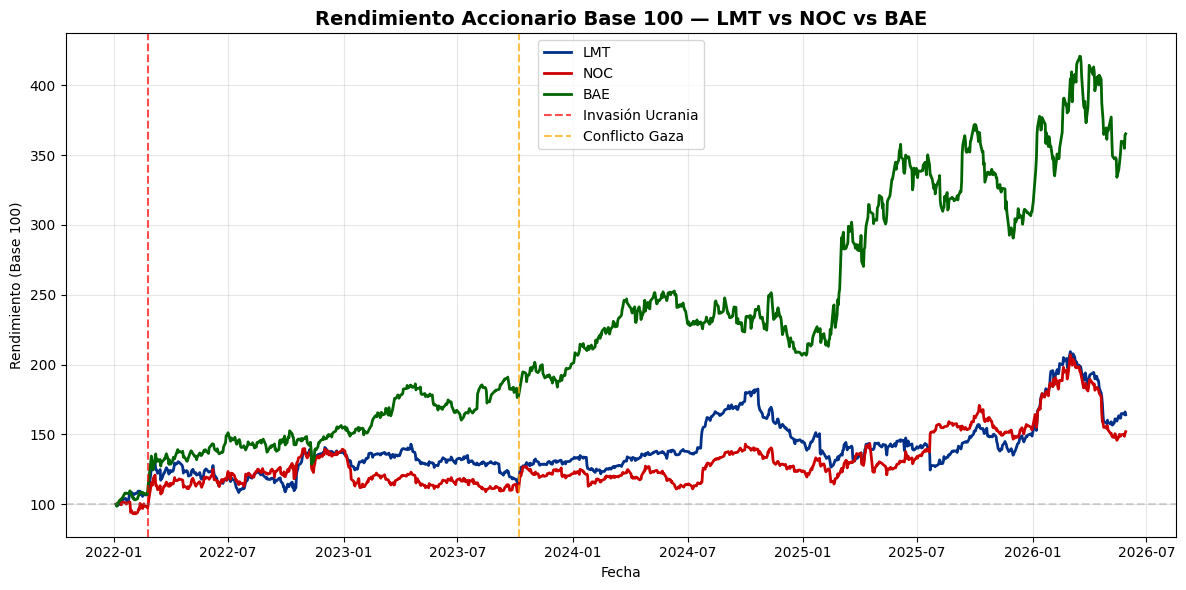

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(precios_norm.index, precios_norm['LMT'], 
        linewidth=2, label='LMT', color='#003087')
ax.plot(precios_norm.index, precios_norm['NOC'], 
        linewidth=2, label='NOC', color='#CC0000')
ax.plot(precios_norm.index, precios_norm['BAE'], 
        linewidth=2, label='BAE', color='#006400')

# Eventos geopolíticos clave
ax.axvline(pd.Timestamp('2022-02-24'), color='red', 
           linestyle='--', alpha=0.7, label='Invasión Ucrania')
ax.axvline(pd.Timestamp('2023-10-07'), color='orange', 
           linestyle='--', alpha=0.7, label='Conflicto Gaza')

ax.axhline(y=100, color='gray', linestyle='--', alpha=0.3)
ax.set_title('Rendimiento Accionario Base 100 — LMT vs NOC vs BAE', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Rendimiento (Base 100)')
ax.set_xlabel('Fecha')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [22]:
# Tabla 1 — Métricas financieras en formato largo
registros = []

empresas_data = {
    'LMT': {'revenue': lmt_revenue, 'utilidad': utilidad_neta, 'margen': margen_neto},
    'NOC': {'revenue': noc_revenue, 'utilidad': noc_utilidad, 'margen': margen_noc},
    'BAE': {'revenue': bae_revenue, 'utilidad': bae_utilidad, 'margen': margen_bae}
}

for empresa, metricas in empresas_data.items():
    for año in metricas['revenue'].index:
        registros.append({
            'Año': año.year,
            'Empresa': empresa,
            'Ingresos_USD_M': metricas['revenue'].get(año, None),
            'Utilidad_USD_M': metricas['utilidad'].get(año, None),
            'Margen_Neto_PCT': metricas['margen'].get(año, None)
        })

df_financiero = pd.DataFrame(registros)
print(df_financiero.sort_values(['Año', 'Empresa']))

     Año Empresa  Ingresos_USD_M  Utilidad_USD_M  Margen_Neto_PCT
8   2022     BAE        26982.78         2019.46             7.48
0   2022     LMT        65984.00         5732.00             8.69
4   2022     NOC        36602.00         4896.00            13.38
9   2023     BAE        29292.91         2357.09             8.05
1   2023     LMT        67571.00         6920.00            10.24
5   2023     NOC        39290.00         2056.00             5.23
10  2024     BAE        33397.82         2482.75             7.43
2   2024     LMT        71043.00         5336.00             7.51
6   2024     NOC        41033.00         4174.00            10.17
11  2025     BAE        35966.88         2617.30             7.28
3   2025     LMT        75048.00         5017.00             6.69
7   2025     NOC        41954.00         4182.00             9.97


In [23]:
# Tabla 2 — Precios base 100
df_precios = precios_norm.reset_index()
df_precios.columns = ['Fecha', 'LMT', 'NOC', 'BAE']
df_precios['Fecha'] = df_precios['Fecha'].dt.strftime('%Y-%m-%d')

# Exportamos ambas tablas
df_financiero.to_csv('metricas_defensa.csv', index=False)
df_precios.to_csv('precios_defensa.csv', index=False)

print("✅ metricas_defensa.csv exportado")
print("✅ precios_defensa.csv exportado")
print(f"\nRegistros financieros: {len(df_financiero)}")
print(f"Registros de precios: {len(df_precios)}")

✅ metricas_defensa.csv exportado
✅ precios_defensa.csv exportado

Registros financieros: 12
Registros de precios: 1082


In [24]:
# Convertimos precios a formato largo
df_precios_largo = df_precios.melt(
    id_vars=['Fecha'],
    value_vars=['LMT', 'NOC', 'BAE'],
    var_name='Empresa',
    value_name='Precio_Base100'
)

df_precios_largo = df_precios_largo.sort_values(['Fecha', 'Empresa'])
df_precios_largo['Precio_Base100'] = df_precios_largo['Precio_Base100'].round(2)

print(df_precios_largo.head(9))
df_precios_largo.to_csv('precios_defensa_largo.csv', index=False)
print("\n✅ precios_defensa_largo.csv exportado")

           Fecha Empresa  Precio_Base100
2164  2022-01-04     BAE          100.00
0     2022-01-04     LMT          100.00
1082  2022-01-04     NOC          100.00
2165  2022-01-05     BAE           98.63
1     2022-01-05     LMT           98.94
1083  2022-01-05     NOC           99.50
2166  2022-01-06     BAE           99.13
2     2022-01-06     LMT           98.90
1084  2022-01-06     NOC          100.07

✅ precios_defensa_largo.csv exportado
